# WPC QPF Precipitation Forecast to DSS

This notebook uses `qpkit` v0.1.0 to select a current Weather Prediction Center (WPC) quantitative precipitation forecast, download its 2.5 km GRIB grids, crop and reproject them for a regional HEC-DSS file, and verify the resulting catalog with `RasDss`.

**Series position:** Use `915_realtime_forecast_workflow.ipynb` for the complete operational sequence. This notebook isolates the WPC QPF acquisition and DSS-write mechanics for forecast precipitation forcing.

## Prerequisites and Constraints

Install the optional dependency from a terminal at the repository root, not from a notebook cell:

```console
uv pip install "git+https://github.com/gyanz/qpkit.git@v0.1.0"
```

This workflow has deliberate operational constraints:

- `QPFRequest` v0.1.0 reads the current UTC day's WPC directory; it has no historical date parameter and does not fall back to the previous day.
- Six-hour QPF cycles are nominally 00Z, 06Z, 12Z, and 18Z. The workflow probes eligible cycles from newest to oldest for the current UTC date, requires the complete `f006` through `f168` sequence, and reports any incomplete newer cycle that it rejects.
- `QPFGridOptions.extents` crops during the DSS-write stage. The source WPC GRIB files are still downloaded at their published CONUS extent.
- Each source file is a discrete six-hour accumulation. qpkit derives the DSS D and E parts from the cycle, forecast hour, and accumulation interval encoded in the filename.
- Live WPC access, the `pydsstools` grid stack, and a Java runtime for `RasDss.get_catalog()` are required. Failures are raised rather than converted to a successful demonstration.
- The example demonstrates API mechanics. Select forecast products, extents, resolution, and model use according to project requirements and applicable guidance.

## Setup and Imports

In [1]:
# True uses the local checkout; False uses the installed ras-commander package.
USE_LOCAL_SOURCE = True

import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "examples":
    REPO_ROOT = REPO_ROOT.parent

if USE_LOCAL_SOURCE:
    local_path = str(REPO_ROOT)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)

In [2]:
from datetime import datetime, timedelta, timezone
from importlib.metadata import version as package_version
import logging
import re
import warnings

from qpkit import BoundingBox, QPFGridOptions, QPFRequest, QPKit

QPKIT_VERSION = package_version("qpkit")
if QPKIT_VERSION != "0.1.0":
    raise RuntimeError(f"This workflow requires qpkit 0.1.0; found {QPKIT_VERSION}")

qpkit_logger = logging.getLogger("qpkit")
qpkit_logger.setLevel(logging.WARNING)

run_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
QPF_RUN_ROOT = REPO_ROOT / "working" / "example_926_wpc_qpf_to_dss" / run_stamp
QPF_GRIB_DIR = QPF_RUN_ROOT / "grib"
QPF_DSS_FILE = QPF_RUN_ROOT / "wpc_qpf_southeast_texas.dss"
QPF_GRIB_DIR.mkdir(parents=True, exist_ok=False)
if QPF_DSS_FILE.exists():
    raise RuntimeError(f"Fresh-run DSS target already exists: {QPF_DSS_FILE}")

## Configure the Request and Regional Grid

The bounding box limits the DSS grid to southeast Texas. The 2,500 m destination cell size follows the nominal source resolution while the default qpkit SHG projection supplies HEC-compatible spatial grid metadata.

In [3]:
QPF_INTERVAL_HOURS = 6
EXPECTED_QPF_FORECAST_HOURS = tuple(range(6, 169, QPF_INTERVAL_HOURS))
WPC_CYCLE_HOURS = (0, 6, 12, 18)
SOUTHEAST_TEXAS_BBOX = BoundingBox(
    left_lon=-97.8,
    right_lon=-94.5,
    top_lat=31.5,
    bottom_lat=28.5,
)

qpf_grid_options = QPFGridOptions(
    part_a="WPC",
    part_b="SOUTHEAST_TEXAS",
    part_c="PRECIP",
    part_f="QPF-6H",
    cell_size=2500.0,
    extents=SOUTHEAST_TEXAS_BBOX,
    overwrite=False,
)

## Select a Current Cycle and Write DSS

`build_plan_qpf()` is used only to find the newest eligible current-day cycle with published files. `download_to_dss()` then performs the actual download and QPF grid write. qpkit logging is held at WARNING so per-file INFO messages do not obscure the explicit verified summary below.

In [4]:
current_utc = datetime.now(timezone.utc)
candidate_cycles = tuple(
    cycle for cycle in reversed(WPC_CYCLE_HOURS) if cycle <= current_utc.hour
)

def qpf_forecast_hours(items) -> tuple[int, ...]:
    hours = []
    for item in items:
        filename = item.filename if hasattr(item, "filename") else Path(item).name
        match = re.search(r"f(\d{3})\.grb$", Path(filename).name)
        if match is None:
            raise RuntimeError(f"Could not parse WPC QPF forecast hour: {filename}")
        hours.append(int(match.group(1)))
    return tuple(sorted(hours))


rejected_cycles = []
with QPKit(logger=qpkit_logger) as kit:
    qpf_request = None
    for cycle_hour in candidate_cycles:
        candidate_request = QPFRequest(
            interval=QPF_INTERVAL_HOURS,
            cycle_hour=cycle_hour,
        )
        candidate_plan = kit.build_plan_qpf(candidate_request, QPF_GRIB_DIR)
        candidate_hours = qpf_forecast_hours(candidate_plan.items)
        if candidate_hours == EXPECTED_QPF_FORECAST_HOURS:
            qpf_request = candidate_request
            selected_cycle_hour = cycle_hour
            break
        missing_hours = sorted(set(EXPECTED_QPF_FORECAST_HOURS) - set(candidate_hours))
        unexpected_hours = sorted(set(candidate_hours) - set(EXPECTED_QPF_FORECAST_HOURS))
        rejected_cycles.append(
            f"{cycle_hour:02d}Z missing={missing_hours or 'none'} "
            f"unexpected={unexpected_hours or 'none'}"
        )

    if qpf_request is None:
        raise RuntimeError(
            f"No current-day WPC {QPF_INTERVAL_HOURS}-hour QPF files were available for "
            f"candidate cycles {candidate_cycles} on {current_utc:%Y-%m-%d} UTC; "
            f"rejected={rejected_cycles}"
        )

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="You will likely lose important projection information.*",
            category=UserWarning,
            module=r"pyproj\.crs\.crs",
        )
        qpf_result = kit.download_to_dss(
            qpf_request,
            QPF_GRIB_DIR,
            QPF_DSS_FILE,
            grid_options=qpf_grid_options,
            dss_version=7,
            force=False,
        )

downloaded_hours = qpf_forecast_hours(qpf_result.download.succeeded)
if downloaded_hours != EXPECTED_QPF_FORECAST_HOURS:
    raise RuntimeError(
        f"Downloaded WPC QPF hours are incomplete: {downloaded_hours}; "
        f"expected {EXPECTED_QPF_FORECAST_HOURS}"
    )
if qpf_result.download.failed:
    raise RuntimeError(f"WPC QPF downloads failed: {qpf_result.download.failed}")
if qpf_result.download.skipped:
    raise RuntimeError(f"Fresh WPC QPF run unexpectedly skipped files: {qpf_result.download.skipped}")
if not qpf_result.download.succeeded:
    raise RuntimeError("WPC QPF download returned no files")
if any(not path.is_file() or path.stat().st_size == 0 for path in qpf_result.download.succeeded):
    raise RuntimeError("One or more downloaded WPC QPF files are missing or empty")
if qpf_result.dss.failed:
    raise RuntimeError(f"WPC QPF DSS writes failed: {qpf_result.dss.failed}")
if qpf_result.dss.skipped:
    raise RuntimeError(f"Fresh WPC QPF DSS write unexpectedly skipped records: {qpf_result.dss.skipped}")
if len(qpf_result.dss.written) != len(qpf_result.download.succeeded):
    raise RuntimeError(
        f"Downloaded {len(qpf_result.download.succeeded)} QPF files but wrote "
        f"{len(qpf_result.dss.written)} DSS grids"
    )
if not QPF_DSS_FILE.is_file() or QPF_DSS_FILE.stat().st_size == 0:
    raise RuntimeError(f"WPC QPF DSS file was not created: {QPF_DSS_FILE}")

## Verify the Fresh DSS Catalog

A fresh run must contain exactly the pathnames reported as written by qpkit. Extra, missing, or duplicate catalog entries are treated as failures.

qpkit 0.1.0 WPC QPF summary
  Current UTC date: 2026-07-10
  Selected cycle: 12Z
  Rejected incomplete cycle(s): 18Z missing=[144] unexpected=[174]
  Downloaded: 28 GRIB files
  Written and cataloged: 28 DSS grids
  Regional bounds: left_lon=-97.8 right_lon=-94.5 top_lat=31.5 bottom_lat=28.5
  DSS file: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\example_926_wpc_qpf_to_dss\20260710T180914939777Z\wpc_qpf_southeast_texas.dss


,pathname
0,/WPC/SOUTHEAST_TEXAS/PRECIP/10JUL2026:1200/10J...
1,/WPC/SOUTHEAST_TEXAS/PRECIP/10JUL2026:1800/10J...
2,/WPC/SOUTHEAST_TEXAS/PRECIP/11JUL2026:0000/11J...
3,/WPC/SOUTHEAST_TEXAS/PRECIP/11JUL2026:0600/11J...
4,/WPC/SOUTHEAST_TEXAS/PRECIP/11JUL2026:1200/11J...
5,/WPC/SOUTHEAST_TEXAS/PRECIP/11JUL2026:1800/11J...
6,/WPC/SOUTHEAST_TEXAS/PRECIP/12JUL2026:0000/12J...
7,/WPC/SOUTHEAST_TEXAS/PRECIP/12JUL2026:0600/12J...
8,/WPC/SOUTHEAST_TEXAS/PRECIP/12JUL2026:1200/12J...
9,/WPC/SOUTHEAST_TEXAS/PRECIP/12JUL2026:1800/12J...


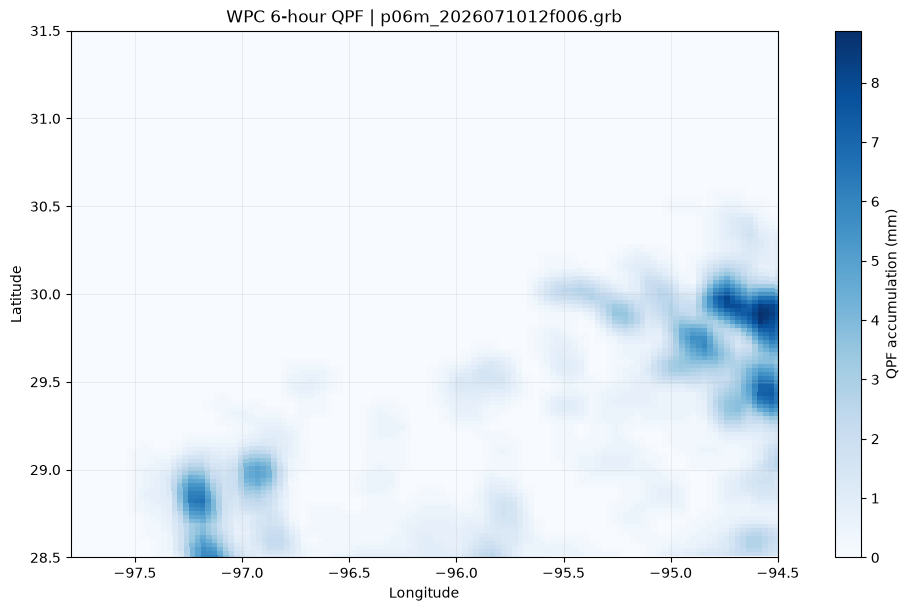

Regional QPF cells: 16,891; range=0.000 to 8.875 mm


In [5]:
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="IProgress not found.*",
        category=Warning,
        module=r"tqdm\.auto",
    )
    from ras_commander import RasDss

qpf_catalog = RasDss.get_catalog(QPF_DSS_FILE)
if "pathname" not in qpf_catalog.columns:
    raise RuntimeError(f"RasDss catalog is missing the pathname column: {qpf_catalog.columns.tolist()}")

def canonical_dss_pathname(pathname: str) -> str:
    parts = str(pathname).strip("/").split("/")
    if len(parts) != 6:
        raise ValueError(f"Expected six DSS pathname parts: {pathname}")
    for index in (3, 4):
        date_text, time_text = parts[index].split(":", 1)
        hour = int(time_text[:2])
        minute = int(time_text[2:])
        timestamp = datetime.strptime(date_text, "%d%b%Y")
        if hour == 24:
            timestamp += timedelta(days=1)
            hour = 0
        timestamp = timestamp.replace(hour=hour, minute=minute)
        parts[index] = timestamp.strftime("%d%b%Y:%H%M").upper()
    return "/" + "/".join(part.upper() for part in parts) + "/"


written_pathnames = {canonical_dss_pathname(path) for path in qpf_result.dss.written}
catalog_pathnames = {
    canonical_dss_pathname(path) for path in qpf_catalog["pathname"].astype(str)
}
if len(qpf_catalog) != len(catalog_pathnames):
    raise RuntimeError("RasDss catalog contains duplicate WPC QPF pathnames")
if catalog_pathnames != written_pathnames:
    missing = sorted(written_pathnames - catalog_pathnames)
    unexpected = sorted(catalog_pathnames - written_pathnames)
    raise RuntimeError(f"WPC QPF catalog mismatch; missing={missing}, unexpected={unexpected}")

print(f"qpkit {QPKIT_VERSION} WPC QPF summary")
print(f"  Current UTC date: {current_utc:%Y-%m-%d}")
print(f"  Selected cycle: {selected_cycle_hour:02d}Z")
if rejected_cycles:
    print(f"  Rejected incomplete cycle(s): {'; '.join(rejected_cycles)}")
print(f"  Downloaded: {len(qpf_result.download.succeeded)} GRIB files")
print(f"  Written and cataloged: {len(written_pathnames)} DSS grids")
print(f"  Regional bounds: {SOUTHEAST_TEXAS_BBOX}")
print(f"  DSS file: {QPF_DSS_FILE}")

display(qpf_catalog)

# Inspect one downloaded QPF grid over the same regional extent used for DSS.
import cfgrib
import matplotlib.pyplot as plt
import numpy as np

sample_grib = sorted(qpf_result.download.succeeded, key=lambda path: path.name)[0]
qpf_datasets = cfgrib.open_datasets(sample_grib, backend_kwargs={"indexpath": ""})
qpf_dataset = next(dataset for dataset in qpf_datasets if dataset.data_vars)
preferred_variables = ("tp", "unknown", "APCP_surface")
qpf_variable = next(
    (name for name in preferred_variables if name in qpf_dataset.data_vars),
    next(iter(qpf_dataset.data_vars)),
)
qpf_grid = qpf_dataset[qpf_variable].squeeze()
qpf_values = np.asarray(qpf_grid.values, dtype=float)
latitudes = np.asarray(qpf_grid.coords["latitude"].values, dtype=float)
longitudes = np.asarray(qpf_grid.coords["longitude"].values, dtype=float)
if latitudes.ndim == 1 and longitudes.ndim == 1:
    longitudes, latitudes = np.meshgrid(longitudes, latitudes)
longitudes = np.where(longitudes > 180.0, longitudes - 360.0, longitudes)

regional_mask = (
    (longitudes >= SOUTHEAST_TEXAS_BBOX.left_lon)
    & (longitudes <= SOUTHEAST_TEXAS_BBOX.right_lon)
    & (latitudes >= SOUTHEAST_TEXAS_BBOX.bottom_lat)
    & (latitudes <= SOUTHEAST_TEXAS_BBOX.top_lat)
)
rows, columns = np.where(regional_mask)
if rows.size == 0:
    raise RuntimeError("Downloaded QPF grid does not intersect the configured regional bounds")
row_slice = slice(rows.min(), rows.max() + 1)
column_slice = slice(columns.min(), columns.max() + 1)
regional_values = qpf_values[row_slice, column_slice]
regional_lats = latitudes[row_slice, column_slice]
regional_lons = longitudes[row_slice, column_slice]

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
image = ax.pcolormesh(
    regional_lons,
    regional_lats,
    regional_values,
    shading="auto",
    cmap="Blues",
)
ax.set(
    xlim=(SOUTHEAST_TEXAS_BBOX.left_lon, SOUTHEAST_TEXAS_BBOX.right_lon),
    ylim=(SOUTHEAST_TEXAS_BBOX.bottom_lat, SOUTHEAST_TEXAS_BBOX.top_lat),
    xlabel="Longitude",
    ylabel="Latitude",
    title=f"WPC {QPF_INTERVAL_HOURS}-hour QPF | {sample_grib.name}",
)
ax.grid(alpha=0.2)
source_units = qpf_grid.attrs.get("units", "source units")
display_units = "mm" if str(source_units).startswith("kg m") else source_units
fig.colorbar(image, ax=ax, label=f"QPF accumulation ({display_units})")
plt.show()

finite_regional = regional_values[np.isfinite(regional_values)]
print(
    f"Regional QPF cells: {finite_regional.size:,}; "
    f"range={finite_regional.min():.3f} to {finite_regional.max():.3f} {display_units}"
)
for dataset in qpf_datasets:
    dataset.close()
